# AdaptCLIP MVTec Experiment

MVTec 데이터셋에서 `models.adaptclip.AdaptCLIP`을 기존 heatmap 노트북과 같은 `fit / predict / predict_batch` 인터페이스로 실행합니다.


In [1]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "models").is_dir() and (path / "datasets").is_dir() and (path / "utils").is_dir():
            return path
    raise RuntimeError("Repository root was not found from the current working directory.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) in sys.path:
    sys.path.remove(str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT))

print("repo root:", REPO_ROOT)


repo root: /Users/taehayeong/Desktop/Git_workspace/lab


In [2]:
import numpy as np

import config_mv
from datasets.mvtec import MyData
from models.adaptclip import AdaptCLIP
from utils.metrics import get_image_auc
from utils.visualization import show_result


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(device)


mps


In [4]:
train_data = MyData(
    config_mv.CLASS_NAME,
    phase="train",
    batch_size=config_mv.BATCH_SIZE,
    shuffle=False,
    limit=config_mv.TRAIN_LIMIT,
)

test_data = MyData(
    config_mv.CLASS_NAME,
    phase="test",
    batch_size=config_mv.BATCH_SIZE,
    shuffle=False,
    limit=config_mv.TEST_LIMIT,
    limit_per_class=config_mv.TEST_LIMIT_PER_CLASS,
)

print("class:", config_mv.CLASS_NAME)
print("train:", len(train_data), "test:", len(test_data))


class: bottle
train: 30 test: 40


In [5]:
adaptclip = AdaptCLIP(
    category=config_mv.CLASS_NAME,
    device=device,
    checkpoint_path="mvtec",
    out_size_h=256,
    out_size_w=256,
    img_resize=336,
    img_cropsize=336,
    batch_size=config_mv.BATCH_SIZE,
    use_prompt_query=True,
)

adaptclip.fit(train_data)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded AdaptCLIP checkpoint: /Users/taehayeong/.cache/huggingface/hub/models--csgaobb--AdaptCLIP/snapshots/74697db0b2e991e1e67cedb59ab37d539f876f0f/adaptclip_checkpoints/12_4_128_train_on_mvtec_3adapters_batch8/epoch_15.pth
Loaded compatible AdaptCLIP keys: 5 / 5


In [6]:
scores = []
heatmaps = []
imgs = []

for img, label in test_data:
    score, heatmap = adaptclip.predict(img)
    scores.append(score.item())
    heatmaps.append(heatmap)
    imgs.append(img)

print("scores:", np.round(scores, 4).tolist())


scores: [0.1207, 0.1345, 0.1265, 0.1052, 0.1297, 0.1132, 0.138, 0.0909, 0.1194, 0.1297, 0.1294, 0.1009, 0.131, 0.1382, 0.1228, 0.1194, 0.1165, 0.1162, 0.1213, 0.131, 0.1108, 0.1117, 0.1003, 0.1308, 0.1031, 0.1025, 0.1353, 0.112, 0.1264, 0.1277, 0.1221, 0.103, 0.1041, 0.1276, 0.1319, 0.1223, 0.0913, 0.1203, 0.128, 0.1022]


In [7]:
image_auc = get_image_auc(test_data, adaptclip)
print("image AUROC:", image_auc)


image AUROC: 0.5866666666666667


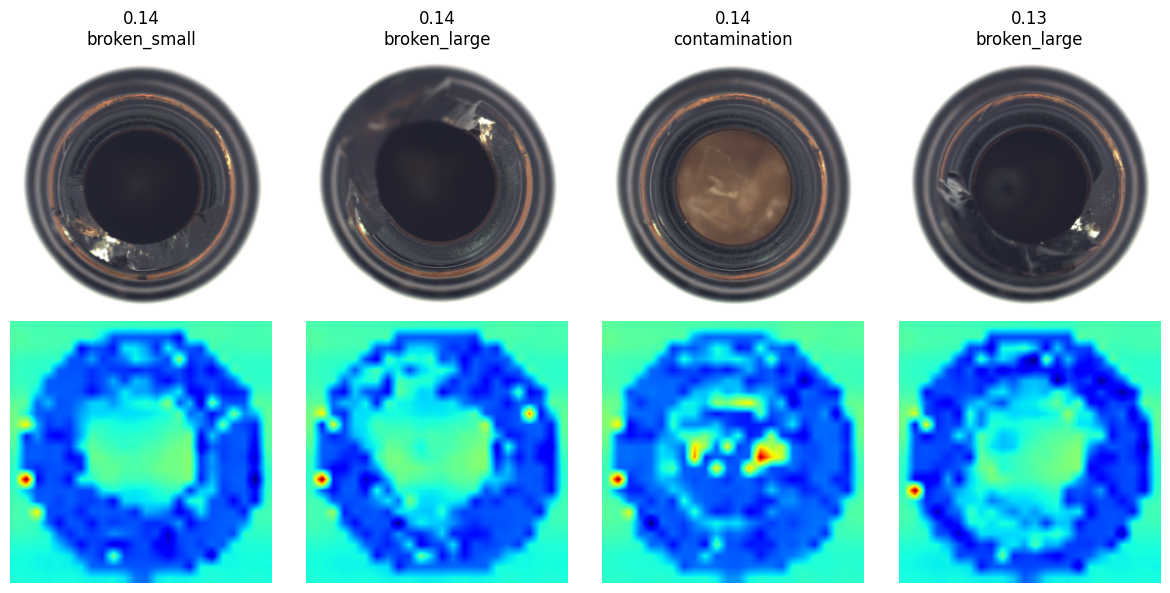

In [8]:
show_result(test_data, scores, heatmaps, k=min(4, len(test_data)))
